In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.9.1+cpu
False


Using device: cpu


[*********************100%***********************]  1 of 1 completed


Data shape: (4680, 1)
Epoch 1/10, Loss: 0.050194
Epoch 2/10, Loss: 0.003098
Epoch 3/10, Loss: 0.000602
Epoch 4/10, Loss: 0.000543
Epoch 5/10, Loss: 0.000516
Epoch 6/10, Loss: 0.000519
Epoch 7/10, Loss: 0.000516
Epoch 8/10, Loss: 0.000527
Epoch 9/10, Loss: 0.000517
Epoch 10/10, Loss: 0.000510
RMSE: 1.3947, MAE: 1.0888, MAPE: 0.40%


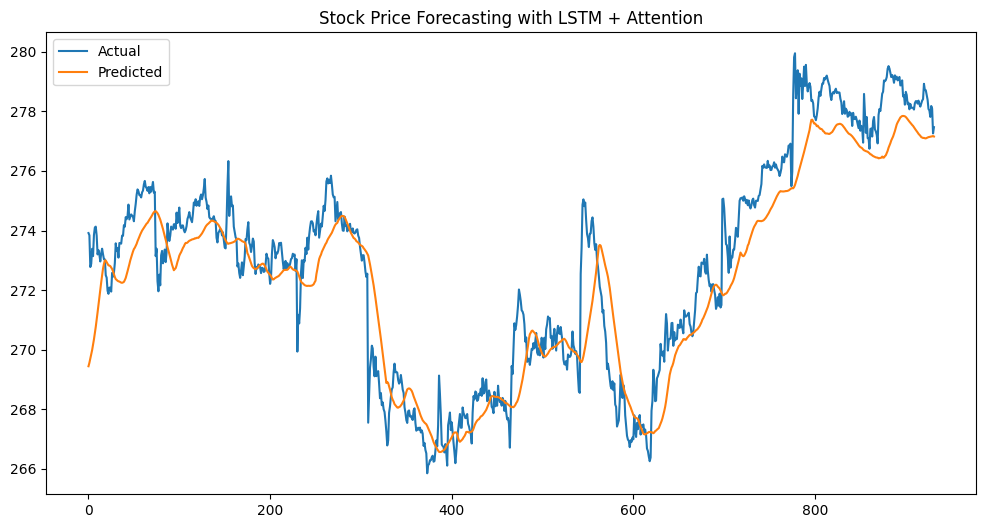

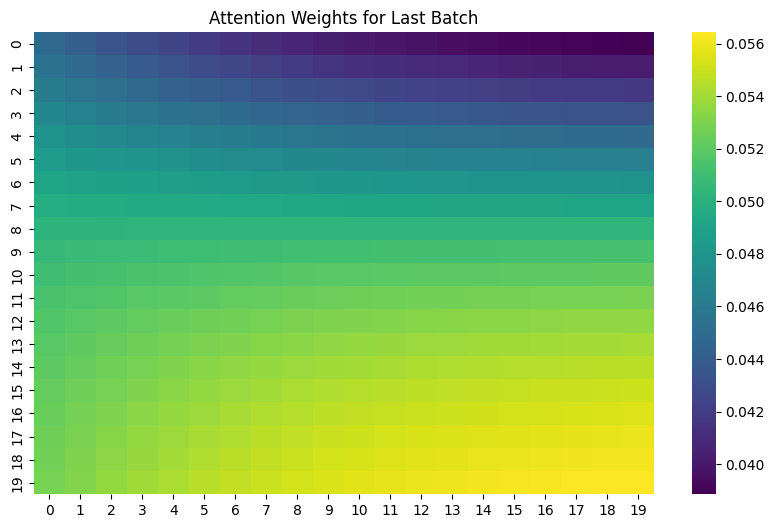

In [14]:
# 1️⃣ Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 3️⃣ Load Data (high-frequency stock data)
symbol = 'AAPL'
data = yf.download(symbol, period='60d', interval='5m')  # 5-min interval for 60 days
data = data[['Close']]
data = data.dropna()
print("Data shape:", data.shape)

# 4️⃣ Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# 5️⃣ Prepare sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 20
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split into train/test
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to torch tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# 6️⃣ Dataset and DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 7️⃣ LSTM + Self-Attention Model
class SelfAttention(nn.Module):
    def __init__(self, input_dim):
        super(SelfAttention, self).__init__()
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attn_weights = self.softmax(torch.bmm(Q, K.transpose(1,2))/np.sqrt(Q.size(-1)))
        out = torch.bmm(attn_weights, V)
        return out, attn_weights

class LSTMAttentionModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2):
        super(LSTMAttentionModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attn = SelfAttention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, attn_weights = self.attn(lstm_out)
        out = self.fc(attn_out[:, -1, :])
        return out, attn_weights

model = LSTMAttentionModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 8️⃣ Training Loop
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out, _ = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {np.mean(train_losses):.6f}")

# 9️⃣ Evaluation
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        out, attn = model(xb)
        preds.append(out.cpu().numpy())
preds = np.concatenate(preds)

# Inverse scale
y_test_np = y_test.cpu().numpy()
preds_inv = scaler.inverse_transform(preds)
y_test_inv = scaler.inverse_transform(y_test_np)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
mae = mean_absolute_error(y_test_inv, preds_inv)
mape = np.mean(np.abs((y_test_inv - preds_inv)/y_test_inv))*100

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%")

# 10️⃣ Plot predictions
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(preds_inv, label="Predicted")
plt.legend()
plt.title("Stock Price Forecasting with LSTM + Attention")
plt.show()

# 11️⃣ Attention weights visualization
plt.figure(figsize=(10,6))
sns.heatmap(attn[0].cpu().numpy(), cmap='viridis')
plt.title("Attention Weights for Last Batch")
plt.show()
